In [18]:
# Import necessary libraries
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler



warnings.filterwarnings('ignore')


nifty50_tickers = [
    "ASIANPAINT.NS", "BRITANNIA.NS", "CIPLA.NS", "EICHERMOT.NS", "NESTLEIND.NS",
        "GRASIM.NS", "HEROMOTOCO.NS", "HINDALCO.NS", "HINDUNILVR.NS", "ITC.NS",
            "LT.NS", "M&M.NS", "RELIANCE.NS", "TATACONSUM.NS", "TATAMOTORS.NS",
                "TATASTEEL.NS", "WIPRO.NS", "APOLLOHOSP.NS", "DRREDDY.NS", "TITAN.NS",
                    "SBIN.NS", "SHRIRAMFIN.NS", "BPCL.NS", "KOTAKBANK.NS", "INFY.NS",
                        "BAJFINANCE.NS", "ADANIENT.NS", "SUNPHARMA.NS", "JSWSTEEL.NS", "HDFCBANK.NS",
                            "TCS.NS", "ICICIBANK.NS", "POWERGRID.NS", "MARUTI.NS", "INDUSINDBK.NS",
                                "AXISBANK.NS", "HCLTECH.NS", "ONGC.NS", "NTPC.NS", "COALINDIA.NS",
                                    "BHARTIARTL.NS", "TECHM.NS", "LTIM.NS", "DIVISLAB.NS", "ADANIPORTS.NS",
                                        "HDFCLIFE.NS", "SBILIFE.NS", "ULTRACEMCO.NS"
                                        ]

# Date Range(10 years time period)
end_date = '2024-07-23'
start_date = pd.to_datetime('2014-01-01')

# Dataset-Yfinance
df = yf.download(tickers=nifty50_tickers,
                            start=start_date,
                             end=end_date).stack()

# Rename the index names for the dataframe(multi index dataframe)
df.index.names = ['date', 'ticker']
df.columns = df.columns.str.lower()
df
#This dataframe is at date level(contains daily stock prices of nifty 50 stocks)



[*********************100%%**********************]  48 of 48 completed


Price                        adj close         close          high  \
date       ticker                                                    
2014-01-01 ADANIENT.NS       37.933197     41.192673     41.368938   
           ADANIPORTS.NS    147.760300    156.300003    157.750000   
           APOLLOHOSP.NS    929.205200    969.299988    987.650024   
           ASIANPAINT.NS    457.836609    499.750000    503.899994   
           AXISBANK.NS      247.552429    258.440002    261.000000   
...                                ...           ...           ...   
2024-07-22 TCS.NS          4276.916016   4287.350098   4319.950195   
           TECHM.NS        1482.236206   1495.550049   1505.849976   
           TITAN.NS        3254.449951   3254.449951   3273.399902   
           ULTRACEMCO.NS  11447.811523  11515.700195  11570.000000   
           WIPRO.NS         505.799988    505.799988    526.750000   

Price                              low          open      volume  
date       ticker                                                 
2014-01-01 ADANIENT.NS       40.204048     40.433960   7564701.0  
           ADANIPORTS.NS    154.550003    154.550003    851727.0  
           APOLLOHOSP.NS    940.250000    940.250000    335988.0  
           ASIANPAINT.NS    492.000000    494.399994   1866326.0  
           AXISBANK.NS      257.640015    260.299988   2849425.0  
...                                ...           ...         ...  
2024-07-22 TCS.NS          4265.000000   4299.950195   1896386.0  
           TECHM.NS        1476.099976   1479.949951   2225781.0  
           TITAN.NS        3223.199951   3250.000000    696255.0  
           ULTRACEMCO.NS  11231.299805  11289.900391    573833.0  
           WIPRO.NS         501.549988    521.000000  38007284.0  

[122298 rows x 6 columns]

In [19]:
#FEATURE ENGINEERING(techincal indicators) using pandas_ta lib

# 1.Garman-Klass Volatility
# Formula: 0.5 * (log(High) - log(Low))^2 - (2*log(2)-1) * (log(Close) - log(Open))^2
df['garman_klass_vol'] = (
    ((np.log(df['high']) - np.log(df['low'])) ** 2) / 2 -
    (2 * np.log(2) - 1) * ((np.log(df['adj close']) - np.log(df['open'])) ** 2)
)

#2. RSI (Relative Strength Index) calculation for a window of 20 days 
df['rsi'] = df.groupby(level=1)['adj close'].transform(
    lambda x: pandas_ta.rsi(close=x, length=20)
)

#3. Bollinger Bands for a window of 20 days
# bb_low: Lower Bollinger Band
df['bb_low'] = df.groupby(level=1)['adj close'].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 0]
)
# bb_mid: Middle Bollinger Band (SMA)
df['bb_mid'] = df.groupby(level=1)['adj close'].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 1]
)
# bb_high: Upper Bollinger Band
df['bb_high'] = df.groupby(level=1)['adj close'].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 2]
)

#4. ATR (Average True Range):
def compute_atr(stock_data):
    atr = pandas_ta.atr(
        high=stock_data['high'],
        low=stock_data['low'],
        close=stock_data['close'],
        length=14
    )
    return atr.sub(atr.mean()).div(atr.std())#Normalizing

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

#5. MACD (Moving Average Convergence Divergence): 
def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:, 0]
    return macd.sub(macd.mean()).div(macd.std())#Normalizing

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)

#5. Traded Value in crores inr: (Adjusted Close Price * Volume) / 1 crore
df['traded_value'] = (df['adj close'] * df['volume']) / 1e7

# Display the resulting dataframe
df


Price                        adj close         close          high  \
date       ticker                                                    
2014-01-01 ADANIENT.NS       37.933197     41.192673     41.368938   
           ADANIPORTS.NS    147.760300    156.300003    157.750000   
           APOLLOHOSP.NS    929.205200    969.299988    987.650024   
           ASIANPAINT.NS    457.836609    499.750000    503.899994   
           AXISBANK.NS      247.552429    258.440002    261.000000   
...                                ...           ...           ...   
2024-07-22 TCS.NS          4276.916016   4287.350098   4319.950195   
           TECHM.NS        1482.236206   1495.550049   1505.849976   
           TITAN.NS        3254.449951   3254.449951   3273.399902   
           ULTRACEMCO.NS  11447.811523  11515.700195  11570.000000   
           WIPRO.NS         505.799988    505.799988    526.750000   

Price                              low          open      volume  \
date       ticker                                                  
2014-01-01 ADANIENT.NS       40.204048     40.433960   7564701.0   
           ADANIPORTS.NS    154.550003    154.550003    851727.0   
           APOLLOHOSP.NS    940.250000    940.250000    335988.0   
           ASIANPAINT.NS    492.000000    494.399994   1866326.0   
           AXISBANK.NS      257.640015    260.299988   2849425.0   
...                                ...           ...         ...   
2024-07-22 TCS.NS          4265.000000   4299.950195   1896386.0   
           TECHM.NS        1476.099976   1479.949951   2225781.0   
           TITAN.NS        3223.199951   3250.000000    696255.0   
           ULTRACEMCO.NS  11231.299805  11289.900391    573833.0   
           WIPRO.NS         501.549988    521.000000  38007284.0   

Price                     garman_klass_vol        rsi    bb_low    bb_mid  \
date       ticker                                                           
2014-01-01 ADANIENT.NS           -0.001167        NaN       NaN       NaN   
           ADANIPORTS.NS         -0.000570        NaN       NaN       NaN   
           APOLLOHOSP.NS          0.001156        NaN       NaN       NaN   
           ASIANPAINT.NS         -0.001995        NaN       NaN       NaN   
           AXISBANK.NS           -0.000890        NaN       NaN       NaN   
...                                    ...        ...       ...       ...   
2024-07-22 TCS.NS                 0.000071  68.544062  8.221046  8.296440   
           TECHM.NS               0.000198  68.006882  7.216091  7.266403   
           TITAN.NS               0.000119  43.724374  8.053748  8.102358   
           ULTRACEMCO.NS          0.000367  56.819841  9.295017  9.349156   
           WIPRO.NS               0.000863  47.918609  6.190867  6.278155   

Price                      bb_high       atr      macd  traded_value  
date       ticker                                                     
2014-01-01 ADANIENT.NS         NaN       NaN       NaN     28.695329  
           ADANIPORTS.NS       NaN       NaN       NaN     12.585144  
           APOLLOHOSP.NS       NaN       NaN       NaN     31.220180  
           ASIANPAINT.NS       NaN       NaN       NaN     85.447237  
           AXISBANK.NS         NaN       NaN       NaN     70.538208  
...                            ...       ...       ...           ...  
2024-07-22 TCS.NS         8.371835  1.818237  3.097202    811.068366  
           TECHM.NS       7.316715  1.295836  2.252060    329.913318  
           TITAN.NS       8.150967  1.384021 -1.672652    226.592705  
           ULTRACEMCO.NS  9.403295  3.415309  1.934515    656.913203  
           WIPRO.NS       6.365442  2.439437  2.184315   1922.408378  

[122298 rows x 14 columns]

In [20]:
# Aggregate to monthly level 

# Create a list of column names, excluding those related to volume, price levels, and some others.
last_cols = [c for c in df.columns.unique(0)
             if c not in ['traded_value', 'volume', 'open', 'high', 'low', 'close']]

# 1. Converting the daily 'traded_value' data to monthly frequency by taking the mean.
# 2. Convert the rest of the daily data (from last_cols) to monthly frequency by taking the last value of the month(i.e value at last date of the month).

data = (pd.concat([
    df.unstack('ticker')['traded_value'].resample('M').mean().stack('ticker').to_frame('traded_value'),
    df.unstack()[last_cols].resample('M').last().stack('ticker')
], axis=1)).dropna()

# Display the aggregated monthly data.
data
# data dataframe is at monthly level

traded_value     adj close       atr   bb_high  \
date       ticker                                                          
2014-02-28 ADANIENT.NS       50.848794     35.886566 -0.672960  3.627210   
           ADANIPORTS.NS     28.371963    158.112030 -1.008562  5.090981   
           APOLLOHOSP.NS     10.660637    882.232117 -1.058785  6.819753   
           ASIANPAINT.NS     31.880633    433.330109 -1.404543  6.109191   
           AXISBANK.NS      178.542511    242.734329 -1.818114  5.488804   
...                                ...           ...       ...       ...   
2024-07-31 TCS.NS          1460.302135   4276.916016  1.818237  8.371835   
           TECHM.NS         286.641176   1482.236206  1.295836  7.316715   
           TITAN.NS         468.239728   3254.449951  1.384021  8.150967   
           ULTRACEMCO.NS    478.069003  11447.811523  3.415309  9.403295   
           WIPRO.NS         648.222323    505.799988  2.439437  6.365442   

                            bb_low    bb_mid  garman_klass_vol      macd  \
date       ticker                                                          
2014-02-28 ADANIENT.NS    3.420942  3.524076         -0.000951 -0.135196   
           ADANIPORTS.NS  4.874476  4.982728          0.001618  0.037978   
           APOLLOHOSP.NS  6.759809  6.789781          0.000539 -0.319632   
           ASIANPAINT.NS  6.046667  6.077929         -0.003364 -0.305079   
           AXISBANK.NS    5.313929  5.401367          0.000172  0.016891   
...                            ...       ...               ...       ...   
2024-07-31 TCS.NS         8.221046  8.296440          0.000071  3.097202   
           TECHM.NS       7.216091  7.266403          0.000198  2.252060   
           TITAN.NS       8.053748  8.102358          0.000119 -1.672652   
           ULTRACEMCO.NS  9.295017  9.349156          0.000367  1.934515   
           WIPRO.NS       6.190867  6.278155          0.000863  2.184315   

                                rsi  
date       ticker                    
2014-02-28 ADANIENT.NS    57.971217  
           ADANIPORTS.NS  63.501736  
           APOLLOHOSP.NS  46.912821  
           ASIANPAINT.NS  45.281466  
           AXISBANK.NS    65.044802  
...                             ...  
2024-07-31 TCS.NS         68.544062  
           TECHM.NS       68.006882  
           TITAN.NS       43.724374  
           ULTRACEMCO.NS  56.819841  
           WIPRO.NS       47.918609  

[5927 rows x 9 columns]

In [21]:

# Calculating the 2-year rolling average of tradeed value for each stock.(2 yr rolling window with minimum of 12 months to calculate mean)


data['traded_value'] = (data.loc[:, 'traded_value'].unstack('ticker')
                         .rolling(2*12, min_periods=12).mean()
                         .stack())

# Calculate Monthly Returns for different time horizons as features.

# function to calculate monthly returns for various lag periods(1,2,3,6,9,12)
# also handles outliers by clipping return values outside a certain range.
def calculate_returns(df):

    # Define an outlier cutoff threshold. Returns beyond this threshold (both on the low and high side) will be treated as outliers.
    outlier_cutoff = 0.005

    # Define different time horizons (in months) for which we want to calculate returns.
    lags = [1, 2, 3, 6, 9, 12]

    # Loop over each lag to calculate the return for that time horizon.
    for lag in lags:

        df[f'returns_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df
# Apply the 'calculate_returns' function to our data grouped by ticker (level=1).
# Drop rows with NaN values after the calculation.
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

# Display the resulting dataframe with returns for each specified time horizon.
data



traded_value     adj close       atr   bb_high  \
date       ticker                                                          
2015-02-28 ADANIENT.NS      122.085503    102.533714 -0.617109  4.658778   
           ADANIPORTS.NS     89.249232    328.578400 -0.305641  5.813360   
           APOLLOHOSP.NS     17.946249   1254.989136 -0.589340  7.188020   
           ASIANPAINT.NS     73.277349    747.237122 -0.750378  6.668535   
           AXISBANK.NS      214.172761    548.913818  0.157384  6.365857   
...                                ...           ...       ...       ...   
2024-07-31 TCS.NS           745.295474   4276.916016  1.818237  8.371835   
           TECHM.NS         275.209125   1482.236206  1.295836  7.316715   
           TITAN.NS         315.400369   3254.449951  1.384021  8.150967   
           ULTRACEMCO.NS    307.390584  11447.811523  3.415309  9.403295   
           WIPRO.NS         284.904256    505.799988  2.439437  6.365442   

                            bb_low    bb_mid  garman_klass_vol      macd  \
date       ticker                                                          
2015-02-28 ADANIENT.NS    4.482674  4.570726          0.000207 -0.044562   
           ADANIPORTS.NS  5.667380  5.740370          0.002080 -0.029960   
           APOLLOHOSP.NS  7.080574  7.134297         -0.000250  0.133185   
           ASIANPAINT.NS  6.591622  6.630079         -0.001608 -0.278184   
           AXISBANK.NS    6.255230  6.310544          0.000580  0.077090   
...                            ...       ...               ...       ...   
2024-07-31 TCS.NS         8.221046  8.296440          0.000071  3.097202   
           TECHM.NS       7.216091  7.266403          0.000198  2.252060   
           TITAN.NS       8.053748  8.102358          0.000119 -1.672652   
           ULTRACEMCO.NS  9.295017  9.349156          0.000367  1.934515   
           WIPRO.NS       6.190867  6.278155          0.000863  2.184315   

                                rsi  returns_1m  returns_2m  returns_3m  \
date       ticker                                                         
2015-02-28 ADANIENT.NS    68.786398    0.133987    0.209455    0.157282   
           ADANIPORTS.NS  59.626957    0.015247    0.041755    0.060570   
           APOLLOHOSP.NS  54.710230   -0.008679    0.073616    0.037484   
           ASIANPAINT.NS  49.426231   -0.058991    0.035814    0.027206   
           AXISBANK.NS    56.218286   -0.035623    0.062488    0.056309   
...                             ...         ...         ...         ...   
2024-07-31 TCS.NS         68.544062    0.100703    0.081954    0.042481   
           TECHM.NS       68.006882    0.064954    0.113545    0.064305   
           TITAN.NS       43.724374   -0.043990    0.003572   -0.031059   
           ULTRACEMCO.NS  56.819841   -0.013044    0.077675    0.049152   
           WIPRO.NS       47.918609   -0.017578    0.074368    0.030355   

                          returns_6m  returns_9m  returns_12m  
date       ticker                                              
2015-02-28 ADANIENT.NS      0.068168    0.047383     0.091427  
           ADANIPORTS.NS    0.034282    0.048216     0.062852  
           APOLLOHOSP.NS    0.017532    0.041529     0.029804  
           ASIANPAINT.NS    0.044239    0.054112     0.046454  
           AXISBANK.NS      0.061139    0.050687     0.063166  
...                              ...         ...          ...  
2024-07-31 TCS.NS           0.021229    0.028510     0.020206  
           TECHM.NS         0.022402    0.034650     0.027220  
           TITAN.NS        -0.020517    0.002601     0.006968  
           ULTRACEMCO.NS    0.020972    0.035371     0.027477  
           WIPRO.NS         0.009414    0.031987     0.018864  

[5351 rows x 15 columns]

In [22]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import joblib  # For saving scalers


In [23]:

if isinstance(data.index, pd.MultiIndex):
    data = data.reset_index()


In [24]:
# FEATURE SELECTION
features = [
    'traded_value', 'atr', 'bb_high', 'bb_low', 'bb_mid',
    'garman_klass_vol', 'macd', 'rsi',
    'returns_1m', 'returns_2m', 'returns_3m',
    'returns_6m', 'returns_9m', 'returns_12m'
]
target = 'adj close'

# SCALLING THE FEATURES
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

data[features] = feature_scaler.fit_transform(data[features])

# Shift the target column to predict the next month's closing price
data[target] = data.groupby('ticker')[target].shift(-1)

# Drop any NaN values that may have resulted from the shift
data.dropna(inplace=True)

# Split into features and target variable
X = data[features].values
y = data[target].values.reshape(-1, 1)  # Reshape for scaler

# Scale the target variable
y_scaled = target_scaler.fit_transform(y)

print("\nFeatures and Target Scaled:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")



Features and Target Scaled:
X shape: (5303, 14)
y shape: (5303, 1)


In [25]:
# No of time stepss for lstm model =12
time_steps = 12

X_lstm = []
y_lstm = []
tickers = data['ticker'].unique()

for ticker in tickers:
    ticker_data = data[data['ticker'] == ticker].sort_values('date')
    for i in range(time_steps, len(ticker_data)):
        X_lstm.append(X[ticker_data.index[i - time_steps:i]])
        y_lstm.append(y_scaled[ticker_data.index[i]])


X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

print(f"Shape of X_lstm: {X_lstm.shape}")  
print(f"Shape of y_lstm: {y_lstm.shape}")  


Shape of X_lstm: (4727, 12, 14)
Shape of y_lstm: (4727, 1)


In [26]:
# Define the train-test split ratio
test_size = 0.2  # 20% for testing
split_index = int(X_lstm.shape[0] * (1 - test_size))

# Spliting the data
X_train, X_test = X_lstm[:split_index], X_lstm[split_index:]
y_train, y_test = y_lstm[:split_index], y_lstm[split_index:]

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")


Training Samples: 3781
Testing Samples: 946


In [27]:
len(X_test)

946

In [28]:
# LSTM model architecture
model = Sequential([
    Bidirectional(LSTM(100, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(1)  # Output layer for regression
])

#optimizer and loss funct
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional)      │ (None, 12, 200)             │          92,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 200)             │             800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 200)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 100)                 │         120,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,701 (854.30 KB)

 Trainable params: 218,101 (851.96 KB)

 Non-trainable params: 600 (2.34 KB)

In [29]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,  
    batch_size=32,
    validation_split=0.2,  
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.4373 - val_loss: 0.0022
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0868 - val_loss: 0.0123
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0435 - val_loss: 0.0142
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0288 - val_loss: 0.0042
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0154 - val_loss: 0.0054
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0124 - val_loss: 0.0030
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0098 - val_loss: 0.0021
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0076 - val_loss: 0.0010
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0059 - val_loss: 6.3102e-04
Epoch 10/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0061 - val_loss: 0.0017
Epoch 11/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0048 - val_loss: 0.0012
Epoch 12/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/

In [30]:
# Make predictions on the test set
predictions = model.predict(X_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [31]:

# Inverse transform the predictions and actual values to their original scale
predictions_actual = target_scaler.inverse_transform(predictions)
y_test_actual = target_scaler.inverse_transform(y_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_actual, predictions_actual)
mse = mean_squared_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predictions_actual)
mape = mean_absolute_percentage_error(y_test_actual, predictions_actual)

# Print evaluation metrics
print("\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



Model Evaluation Metrics:
Mean Absolute Error (MAE): 237.7811
Mean Squared Error (MSE): 135689.1312
Root Mean Squared Error (RMSE): 368.3601
R-squared (R²): 0.9635
Mean Absolute Percentage Error (MAPE): 0.45%


In [32]:
predictions_actual

array([[ 3.94072479e+02],
       [ 4.35248657e+02],
       [ 4.75373505e+02],
       [ 5.03087524e+02],
       [ 5.57792480e+02],
       [ 5.67941650e+02],
       [ 5.45893005e+02],
       [ 5.54642090e+02],
       [ 5.61768066e+02],
       [ 5.68165588e+02],
       [ 5.91139282e+02],
       [ 6.46320801e+02],
       [ 6.48138367e+02],
       [ 6.50427185e+02],
       [ 6.83758179e+02],
       [ 7.32548889e+02],
       [ 7.38194214e+02],
       [ 7.57130005e+02],
       [ 7.73465271e+02],
       [ 7.89492737e+02],
       [ 7.88598694e+02],
       [ 8.31311951e+02],
       [ 8.45731689e+02],
       [ 9.27453125e+02],
       [ 9.12215210e+02],
       [ 8.70800537e+02],
       [ 7.56995972e+02],
       [ 1.07438269e+03],
       [ 3.68741272e+02],
       [ 4.35649567e+02],
       [ 5.09017548e+02],
       [ 5.85732910e+02],
       [ 5.89742310e+02],
       [ 5.74353149e+02],
       [ 6.07289429e+02],
       [ 6.39688599e+02],
       [ 6.37707764e+02],
       [ 6.34927673e+02],
       [ 6.6

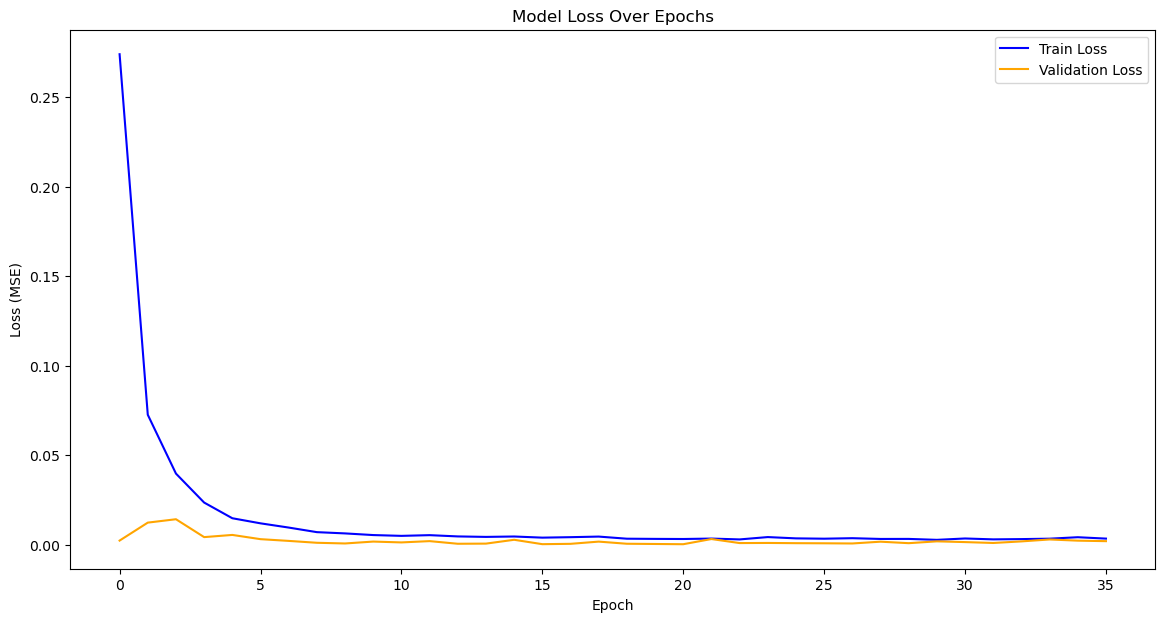

,Actual Closing Price,Predicted Closing Price
0,310.928558,394.072479
1,309.196686,435.248657
2,368.899963,475.373505
3,333.058716,503.087524
4,283.698853,557.792480
...,...,...
941,631.203430,598.633667
942,581.671875,373.602631
943,547.986389,406.304016
944,595.049988,285.701691


In [33]:
# Plot training & validation loss
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()



# Ensure the data is 1D
y_test_actual_1d = y_test_actual.ravel() if len(y_test_actual.shape) > 1 else y_test_actual
predictions_actual_1d = predictions_actual.ravel() if len(predictions_actual.shape) > 1 else predictions_actual

# Prepare the data
predictions_df = pd.DataFrame({
    'Actual Closing Price': y_test_actual_1d,
    'Predicted Closing Price': predictions_actual_1d
})
import cufflinks as cf
cf.go_offline() 

# Plot using cufflinks with solid lines and better labels
predictions_df.iplot(kind='line',
                     title='Actual vs Predicted Closing Prices',
                     xTitle='Time',
                     yTitle='Closing Price (in Rs)',
                     colors=['blue', 'red'],
                     theme='white',
                     mode='lines',  
                     linewidth=3,  
                     asFigure=False,
                     legend=True)
predictions_df



In [34]:
filtered_df = predictions_df[
    abs(predictions_df['Actual Closing Price'] - predictions_df['Predicted Closing Price']) < 50]
filtered_df

,Actual Closing Price,Predicted Closing Price
21,843.085022,831.311951
26,708.914612,756.995972
53,1100.760864,1097.484985
54,1060.250000,1045.889282
72,429.879486,446.999207
...,...,...
903,669.575623,658.329041
908,679.822815,638.491150
916,518.262146,480.694550
936,616.254211,599.664856
